# 2 · Lagrangian perturbation theory up to third order

The displacement is expanded in time-independent shapes times growth factors:
$$\boldsymbol\Psi(\mathbf{q}, a) = D_1\,\boldsymbol\psi_1 + D_2\,\boldsymbol\psi_2
 + D_{3a}\,\boldsymbol\psi_{3a} + D_{3b}\,\boldsymbol\psi_{3b} + D_{3c}\,\boldsymbol\psi_{3c}.$$
The shapes are computed once (optionally dealiased), and the growth factors are cheap to re-evaluate at any
$a$ or cosmology.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from cobox import Box, GRFSampler, IsoModeMask, Particles, Window, ScalarField, stats
from colcdm import LPT, LinearMatterPowSpec, Cosmology

N, L = 64, 250.0                     # 64^3 cells, 250 Mpc/h
box = Box(N, L, 3)
cosmo = Cosmology.from_preset("planck18")
pk = LinearMatterPowSpec(transfer_kind="symbolic_pofk", growth_kind="symbolic_pofk", cosmology=cosmo)
bins = stats.KBins.log(box, 20)
k_th = jnp.logspace(-2.2, 0.1, 200)

/home/prosello/Documents/phd/code/cobox-repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
delta0 = GRFSampler(kind="real").sample_from_seed(0, box, pk)     # linear field at a = 1
basis = LPT(3, dealias=True).get_psi_basis(delta0)               # all shapes, once

## The shapes

Each shape shown through its divergence (longitudinal part) or curl (the transverse $\psi_{3c}$).

div psi_3c ~ 0: 0.2618279457092285


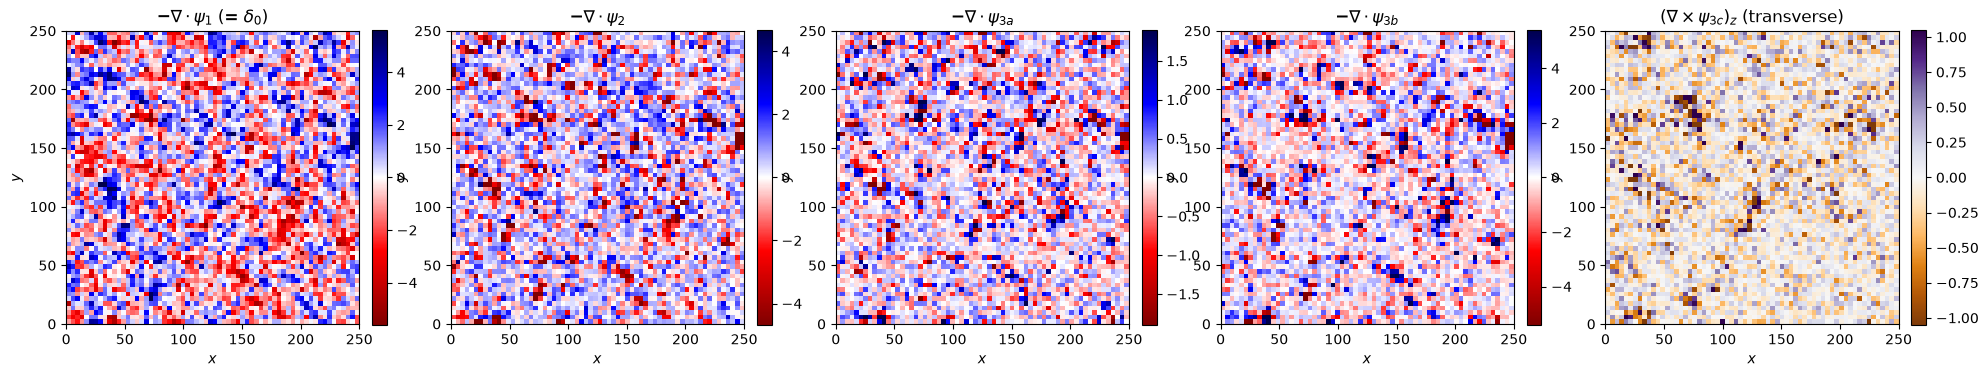

In [3]:
shapes = {
    "$-\\nabla\\cdot\\psi_1$ (= $\\delta_0$)": -basis.s_1.div(),
    "$-\\nabla\\cdot\\psi_2$": -basis.s_2.div(),
    "$-\\nabla\\cdot\\psi_{3a}$": -basis.s_3a.div(),
    "$-\\nabla\\cdot\\psi_{3b}$": -basis.s_3b.div(),
}
fig, axs = plt.subplots(1, 5, figsize=(24, 4.4))
for ax, (title, f) in zip(axs, shapes.items()):
    s = float(jnp.std(f.ifft().data))
    f.paint(ax=ax, cmap="seismic_r", vmin=-3 * s, vmax=3 * s, title=title)
curl_mag = basis.s_3c.curl().ifft()
cz = curl_mag.component(2)
s = float(jnp.std(cz.data))
cz.paint(ax=axs[4], cmap="PuOr", vmin=-3 * s, vmax=3 * s, title="$(\\nabla\\times\\psi_{3c})_z$ (transverse)")
print("div psi_3c ~ 0:", float(jnp.abs(basis.s_3c.div().ifft().data).max()))

## Growth factors

EdS gives $D_2 = -\tfrac37 D_1^2$, etc. In ΛCDM the ratios to EdS deviate by < 2 %; `ode` integrates them,
`fit` is a calibrated power law in $\Omega_m(a)$.

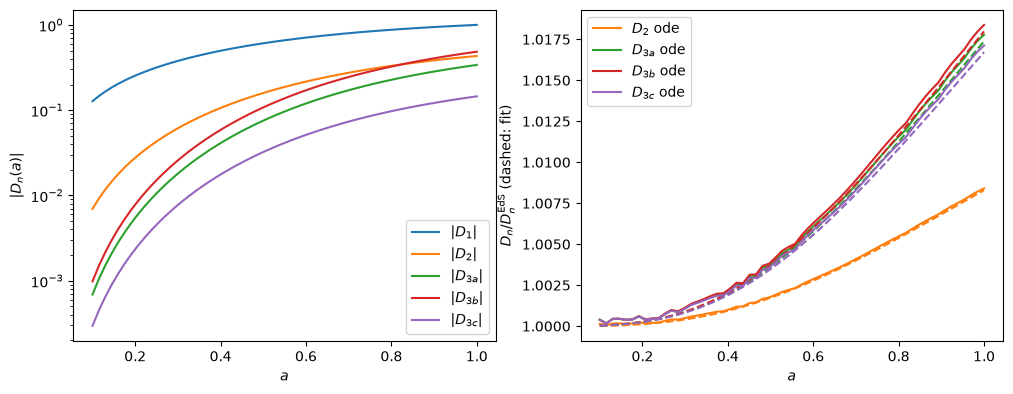

In [4]:
a = jnp.linspace(0.1, 1.0, 60)
keys = ["2", "3a", "3b", "3c"]
co = {kind: LPT(3, lpt_growth_kind=kind).coeffs(a, cosmo) for kind in ("eds", "fit", "ode")}

fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
for key in ["1"] + keys:
    axs[0].plot(a, jnp.abs(co["ode"][key]), label=f"$|D_{{{key}}}|$")
axs[0].set(xlabel="$a$", yscale="log", ylabel="$|D_n(a)|$")
axs[0].legend()
for i, key in enumerate(keys):
    axs[1].plot(a, co["ode"][key] / co["eds"][key], color=f"C{i+1}", label=f"$D_{{{key}}}$ ode")
    axs[1].plot(a, co["fit"][key] / co["eds"][key], color=f"C{i+1}", ls="--")
axs[1].set(xlabel="$a$", ylabel="$D_n / D_n^{\\rm EdS}$ (dashed: fit)")
axs[1].legend();

## Particles at $z = 0$, order by order

A lattice of $64^3$ particles is displaced with 1LPT (Zel'dovich), 2LPT and 3LPT and deposited with PCS.

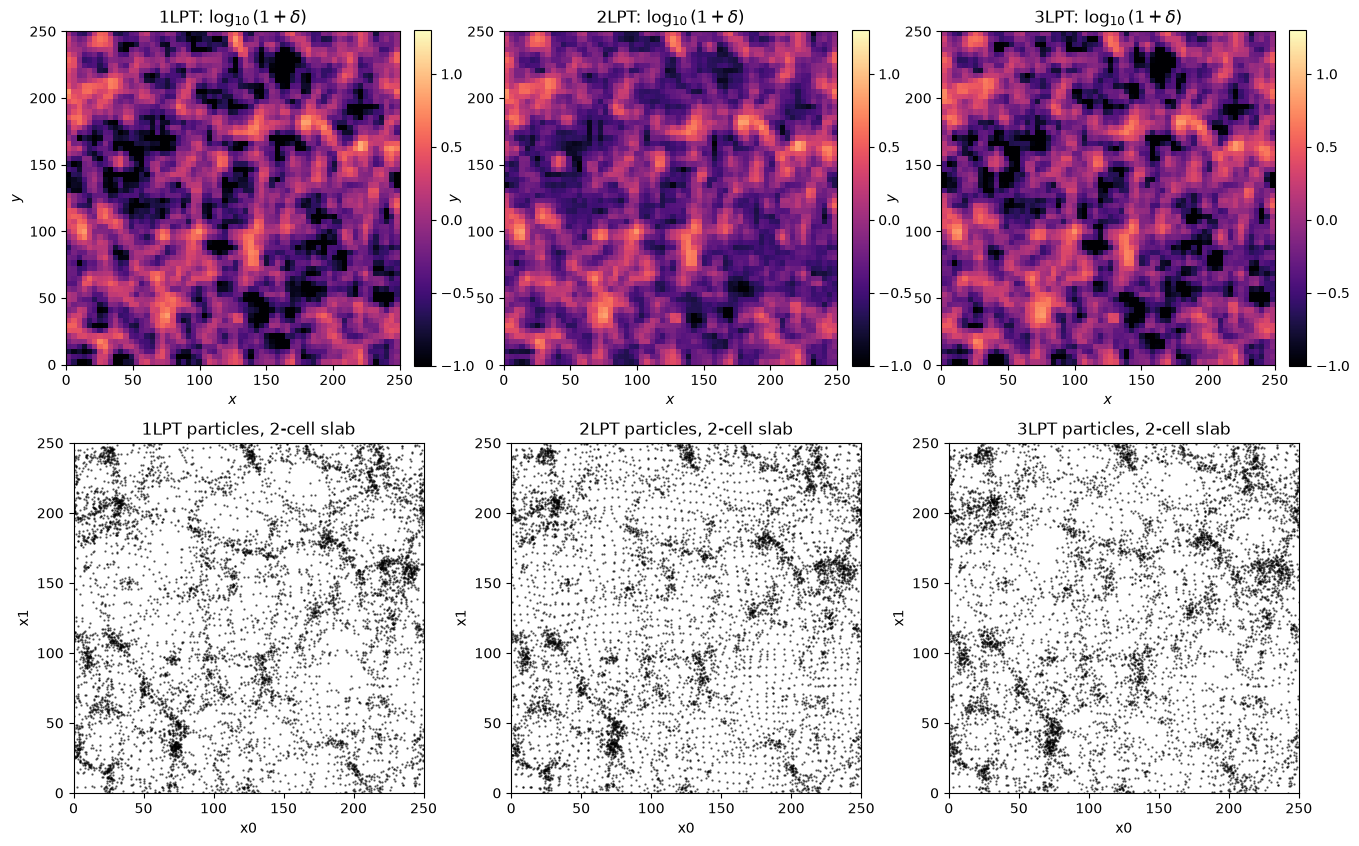

In [5]:
a0 = 1.0
psis = {n: LPT(n, dealias=True).get_psi(delta0, a0, cosmo) for n in (1, 2, 3)}
parts = {n: Particles(box).displace_from_vector_field(p, interpolation=None) for n, p in psis.items()}
pcs = Window("pcs", box.R, normalized=True)
rho = {n: p.deposit(N, bspline_order=3, return_contrast=True) for n, p in parts.items()}

fig, axs = plt.subplots(2, 3, figsize=(16, 10))
for j, n in enumerate((1, 2, 3)):
    (rho[n] + 1.0).paint(ax=axs[0, j], cmap="magma", log_data=True, vmin=-1, vmax=1.3,
                        title=f"{n}LPT: $\\log_{{10}}(1+\\delta)$")
    parts[n].paint(ax=axs[1, j], axis=2, slab=(30, 32), s=0.4, alpha=0.6, c="k", title=f"{n}LPT particles, 2-cell slab")

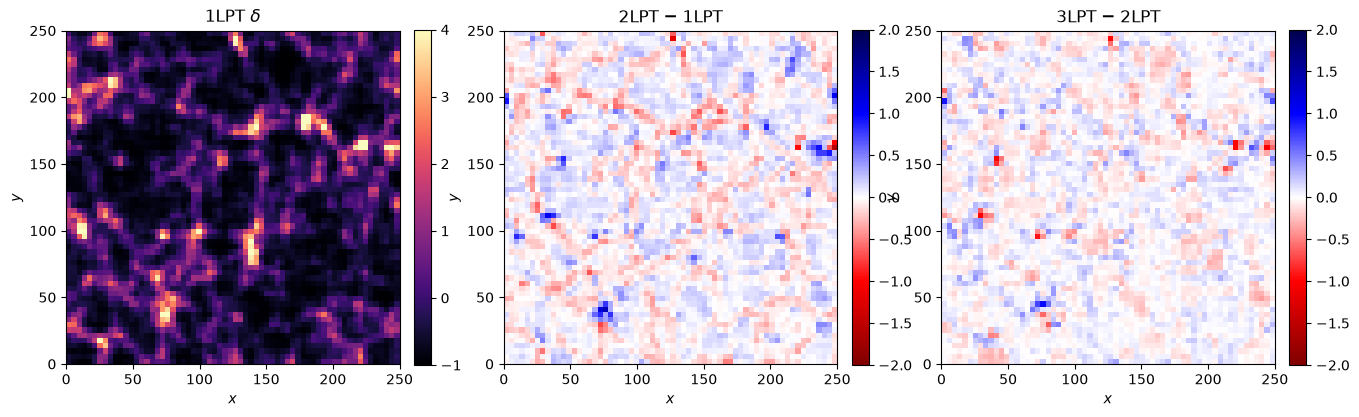

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
d21 = rho[2] - rho[1]
d32 = rho[3] - rho[2]
rho[1].paint(ax=axs[0], cmap="magma", vmin=-1, vmax=4, title="1LPT $\\delta$")
d21.paint(ax=axs[1], cmap="seismic_r", vmin=-2, vmax=2, title="2LPT − 1LPT")
d32.paint(ax=axs[2], cmap="seismic_r", vmin=-2, vmax=2, title="3LPT − 2LPT");

## Statistics

Against the linear field that generated them: the auto spectra, the cross-correlation $r(k)$ and the
propagator $T(k) = P_{\delta\,\delta_L}/P_{\delta_L}$, compared to the Zel'dovich damping
$e^{-k^2\sigma_d^2/2}$ with $\sigma_d^2 = \tfrac13\int P_L\,{\rm d}^3k/(2\pi)^3$.

sigma_d = 5.93 Mpc/h


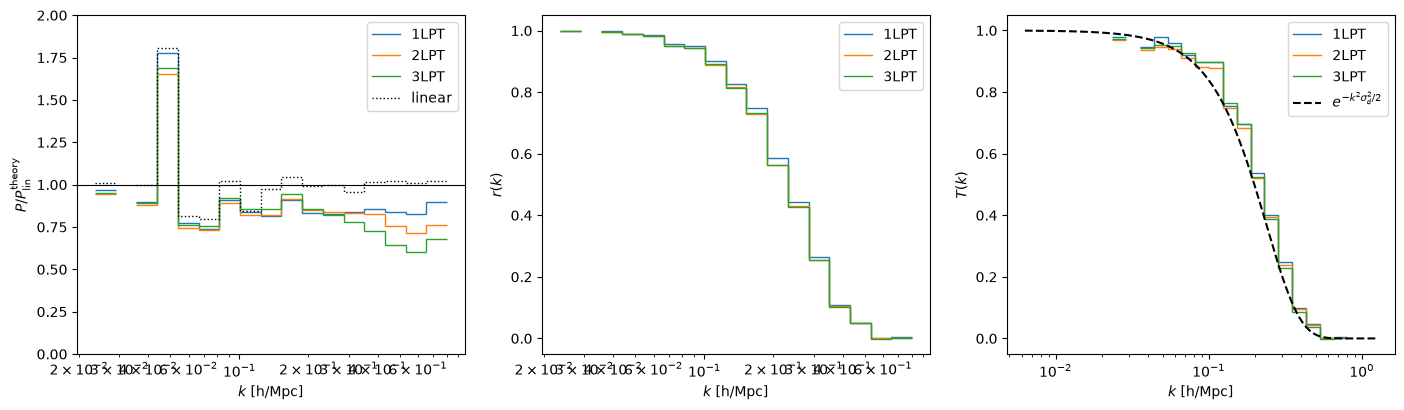

In [7]:
lin = (delta0 * pk.linear_growth(a0) / pk.linear_growth(1.0)).fft()
rho_dc = {n: r.deconvolve(pcs) for n, r in rho.items()}
cc = {n: stats.cross_spectrum(r, lin, bins=bins) for n, r in rho_dc.items()}
sigma_d2 = float(pk.integrate((1e-4, 10.0), a=a0, k_power=1)) / 3
print(f"sigma_d = {sigma_d2 ** 0.5:.2f} Mpc/h")

fig, axs = plt.subplots(1, 3, figsize=(17, 4.4))
for n, c in cc.items():
    c.aa.plot(ax=axs[0], ratio_to=pk, label=f"{n}LPT")
    c.plot("r", ax=axs[1], label=f"{n}LPT")
    c.plot("transfer", ax=axs[2], label=f"{n}LPT")
cc[1].bb.plot(ax=axs[0], ratio_to=pk, color="k", ls=":", label="linear")
axs[0].axhline(1, color="k", lw=0.8)
axs[0].set(ylabel="$P / P_{\\rm lin}^{\\rm theory}$", ylim=(0, 2))
axs[2].plot(k_th, jnp.exp(-0.5 * k_th**2 * sigma_d2), "k--", label="$e^{-k^2\\sigma_d^2/2}$")
axs[1].set(ylabel="$r(k)$")
axs[2].set(ylabel="$T(k)$")
for ax in axs:
    ax.set_xlabel("$k$ [h/Mpc]")
    ax.legend()

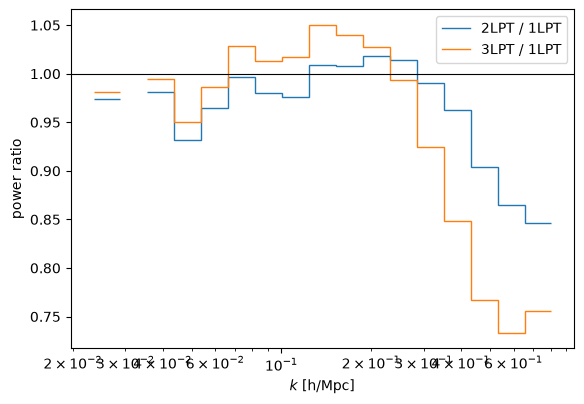

In [8]:
# Same seed, so dividing by 1LPT cancels cosmic variance: the pure effect of higher orders
fig, ax = plt.subplots(figsize=(6.5, 4.4))
for n in (2, 3):
    cc[n].aa.plot(ax=ax, ratio_to=cc[1].aa, label=f"{n}LPT / 1LPT")
ax.axhline(1, color="k", lw=0.8)
ax.set(xlabel="$k$ [h/Mpc]", ylabel="power ratio")
ax.legend();